# PyMC-14 — Modèles de Sequences et Chaînes de Markov Cachees

**Serie** : Programmation Probabiliste avec PyMC (port Python de la serie Infer.NET)
**Duree estimee** : 60 minutes
**Prerequis** : PyMC-13 (Crowdsourcing)

## Objectifs d'apprentissage

1. Comprendre la structure des **Chaînes de Markov Cachees (HMM)**
2. Implementer des **emissions gaussiennes** et inférer les états cachés
3. Appliquer l'algorithme **Forward-Backward** pour le lissage temporel
4. Utiliser les HMM pour la **détection de régimes** et la **détection d'anomalies**

---

**Navigation** : [PyMC-13](PyMC-13-Crowdsourcing.ipynb) | [PyMC-15](PyMC-15-Recommenders.ipynb) | [Infer.NET original](../Infer/Infer-14-Sequences.ipynb)

In [1]:
# Dependances : installer silencieusement seulement ce qui manque.
# (import-guards deterministes : pas de sortie bruyante 'Requirement already satisfied'
#  qui fuie le chemin machine, cf #3436 cause A.)
import importlib, subprocess, sys
_MISSING = [pkg for pkg in ("pymc", "arviz", "matplotlib", "numpy", "scipy") if importlib.util.find_spec(pkg) is None]
if _MISSING:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *_MISSING], check=True)
    print("Paquets installes :", ", ".join(_MISSING))
else:
    print("Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.")


Toutes les dependances (pymc, arviz, matplotlib, numpy, scipy) sont disponibles.


### Import des bibliotheques

Importation de PyMC, ArviZ, NumPy et SciPy pour la modelisation probabiliste et la visualisation.

In [2]:
import warnings
# arviz (FutureWarning de refactor) et pytensor ("could not link BLAS", advisory de perf, pas de correctness)
# leakent le chemin absolu du fichier source site-packages ; on les filtre. Les alertes utiles (R-hat, ESS) restent visibles.
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)

import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az
from scipy.stats import norm

print(f"PyMC version: {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
rng = np.random.default_rng(42)

PyMC version: 6.3.2
ArviZ version: 1.1.0


## 1. Introduction aux Chaînes de Markov Cachees

Un **HMM (Hidden Markov Model)** modelise une sequence d'observations $x_{1:T}$ generees par des etats caches $z_{1:T}$ :

$$P(x_{1:T}, z_{1:T}) = P(z_1) \prod_{t=2}^{T} P(z_t | z_{t-1}) \prod_{t=1}^{T} P(x_t | z_t)$$

**Composants** :
- **Transitions** : $P(z_t | z_{t-1})$ — matrice de transition $A$
- **Emissions** : $P(x_t | z_t)$ — distribution d'observation par etat
- **Etat initial** : $P(z_1)$ — distribution a priori $\pi$

**Applications** :

| Domaine | Etats caches | Observations |
|---------|-------------|-------------|
| NLP | POS tags | Mots |
| Finance | Regimes de marche | Rendements |
| Bioinformatique | Motifs ADN | Sequences nucleotides |
| Meteo | Soleil/Pluie | Temperature |

### References historiques (HMM)

- **Baum & Petrie (1966)** -- *Statistical Inference for Probabilistic Functions of Finite State Markov Chains*, Annals of Mathematical Statistics 37(6). Article fondateur des HMM.
- **Rabiner (1989)** -- *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition*, Proceedings of the IEEE 77(2). Reference pedagogique standard pour les HMM.


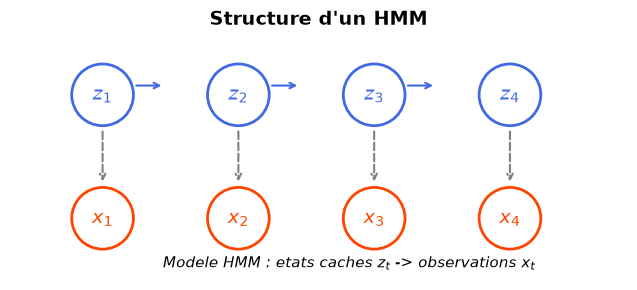

In [3]:
# Visualisation du graphe d'un HMM a 2 etats
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.set_xlim(0, 10)
ax.set_ylim(-1, 3)
ax.set_aspect('equal')
ax.axis('off')

# Hidden states row
for t in range(4):
    x = 1.5 + t * 2.2
    ax.add_patch(plt.Circle((x, 2), 0.5, fill=False, color='royalblue', linewidth=2))
    ax.text(x, 2, f'$z_{t+1}$', ha='center', va='center', fontsize=14, color='royalblue')

# Observations row
for t in range(4):
    x = 1.5 + t * 2.2
    ax.add_patch(plt.Circle((x, 0), 0.5, fill=False, color='orangered', linewidth=2))
    ax.text(x, 0, f'$x_{t+1}$', ha='center', va='center', fontsize=14, color='orangered')

# Transition arrows (horizontal)
for t in range(3):
    x1 = 2.0 + t * 2.2
    x2 = 2.5 + t * 2.2
    ax.annotate('', xy=(x2, 2.15), xytext=(x1, 2.15),
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.5))

# Emission arrows (vertical)
for t in range(4):
    x = 1.5 + t * 2.2
    ax.annotate('', xy=(x, 0.55), xytext=(x, 1.45),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.5, ls='--'))

ax.text(5.5, -0.8, 'Modele HMM : etats caches $z_t$ -> observations $x_t$',
        ha='center', fontsize=11, style='italic')
ax.set_title('Structure d\'un HMM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Classification Independante par Timestep

Avant d'implementer un HMM complet, commencons par classifier chaque observation **independamment** en utilisant la règle de Bayes :

$$P(z_t = k | x_t) \propto P(x_t | z_t = k) \cdot P(z_t = k)$$

Cette approche ignore la structure temporelle — elle traite chaque pas de temps comme un problème de classification indépendant.

In [4]:
# Donnees synthetiques : deux regimes de temperature
# Etat 0 (bas) : mu=10, sigma=2 | Etat 1 (haut) : mu=25, sigma=2
observations = np.array([9.5, 11.2, 10.8, 24.5, 26.1, 25.3, 10.1, 9.8, 11.5, 10.2])
T = len(observations)

# Parametres d'emission connus
means = np.array([10.0, 25.0])
sigmas = np.array([2.0, 2.0])
n_states = 2

# Classification independante (Bayes)
prior = np.array([0.5, 0.5])  # equiprobable

posteriors = np.zeros((T, n_states))
for t in range(T):
    for k in range(n_states):
        posteriors[t, k] = norm.pdf(observations[t], means[k], sigmas[k]) * prior[k]
    posteriors[t] /= posteriors[t].sum()

predicted_states = posteriors.argmax(axis=1)

print("Observations :", observations)
print("Etats predits :", predicted_states)
print()
for t in range(T):
    print(f"  t={t:2d}: x={observations[t]:5.1f} -> P(bas)={posteriors[t,0]:.3f} P(haut)={posteriors[t,1]:.3f}")

Observations : [ 9.5 11.2 10.8 24.5 26.1 25.3 10.1  9.8 11.5 10.2]
Etats predits : [0 0 0 1 1 1 0 0 0 0]

  t= 0: x=  9.5 -> P(bas)=1.000 P(haut)=0.000
  t= 1: x= 11.2 -> P(bas)=1.000 P(haut)=0.000
  t= 2: x= 10.8 -> P(bas)=1.000 P(haut)=0.000
  t= 3: x= 24.5 -> P(bas)=0.000 P(haut)=1.000
  t= 4: x= 26.1 -> P(bas)=0.000 P(haut)=1.000
  t= 5: x= 25.3 -> P(bas)=0.000 P(haut)=1.000
  t= 6: x= 10.1 -> P(bas)=1.000 P(haut)=0.000
  t= 7: x=  9.8 -> P(bas)=1.000 P(haut)=0.000
  t= 8: x= 11.5 -> P(bas)=1.000 P(haut)=0.000
  t= 9: x= 10.2 -> P(bas)=1.000 P(haut)=0.000


### Visualisation de la classification independante

Le graphique montre les observations colorees selon l'etat predit et les probabilites a posteriori correspondantes. Les points proches de la frontiere (entre $\mu_{bas}=10$ et $\mu_{haut}=25$) sont classes uniquement sur l'observation locale.

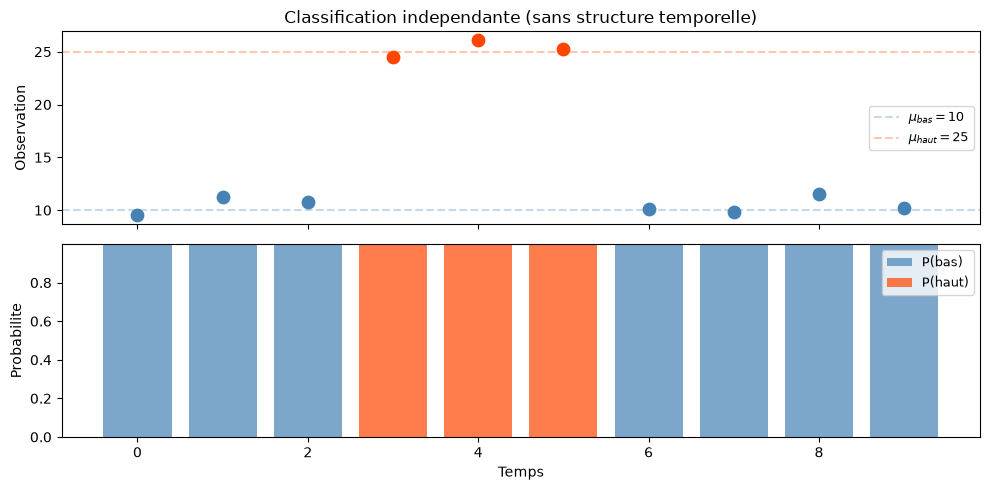

In [5]:
# Visualisation
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

colors = ['steelblue', 'orangered']

# Observations avec couleur par etat predit
for t in range(T):
    axes[0].scatter(t, observations[t], c=colors[predicted_states[t]], s=80, zorder=5)
axes[0].axhline(y=10, color='steelblue', linestyle='--', alpha=0.3, label='$\\mu_{bas}=10$')
axes[0].axhline(y=25, color='orangered', linestyle='--', alpha=0.3, label='$\\mu_{haut}=25$')
axes[0].set_ylabel('Observation')
axes[0].legend(fontsize=9)
axes[0].set_title('Classification independante (sans structure temporelle)')

# Probabilites a posteriori
axes[1].bar(range(T), posteriors[:, 0], color='steelblue', alpha=0.7, label='P(bas)')
axes[1].bar(range(T), posteriors[:, 1], bottom=posteriors[:, 0], color='orangered', alpha=0.7, label='P(haut)')
axes[1].set_ylabel('Probabilite')
axes[1].set_xlabel('Temps')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation

La classification independante fonctionne bien quand les clusters sont bien separes. Mais elle **ignore la dépendance temporelle** : dans un HMM, un etat a $t$ depend de l'etat a $t-1$. Les points ambigus (proches de la frontiere) seraient mieux classes en tenant compte du contexte temporel.

## 3. Algorithme Forward-Backward

L'algorithme **Forward-Backward** calcule exactement $P(z_t = k | x_{1:T})$ en combinant :
- **Forward** ($\alpha$) : $P(z_t, x_{1:t})$ — probabilite de l'etat et des observations passees
- **Backward** ($\beta$) : $P(x_{t+1:T} | z_t)$ — probabilite des observations futures

$$P(z_t = k | x_{1:T}) \propto \alpha_t(k) \cdot \beta_t(k)$$

> L'algorithme Forward-Backward a ete formalise par **Baum, Petrie, Soules & Weiss (1970)** (*A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains*, Annals of Mathematical Statistics 41(1)). Il est un cas special du cadre EM general de **Dempster, Laird & Rubin (1977)** (*Maximum Likelihood from Incomplete Data via the EM Algorithm*, JRSS B 39(1)).


In [6]:
def forward_backward(observations, means, sigmas, trans_mat, prior):
    """
    Algorithme Forward-Backward pour un HMM a emissions gaussiennes.
    
    Parameters
    ----------
    observations : array (T,)
    means : array (K,) - moyennes d'emission par etat
    sigmas : array (K,) - ecarts-types d'emission par etat
    trans_mat : array (K, K) - matrice de transition
    prior : array (K,) - distribution initiale
    
    Returns
    -------
    posteriors : array (T, K) - P(z_t | x_{1:T})
    """
    T = len(observations)
    K = len(means)
    
    # Emission likelihoods : P(x_t | z_t = k)
    B = np.zeros((T, K))
    for t in range(T):
        for k in range(K):
            B[t, k] = norm.pdf(observations[t], means[k], sigmas[k])
    
    # Forward pass : alpha[t, k] = P(z_t=k, x_{1:t})
    alpha = np.zeros((T, K))
    alpha[0] = prior * B[0]
    alpha[0] /= alpha[0].sum()  # normalisation
    
    for t in range(1, T):
        for k in range(K):
            alpha[t, k] = B[t, k] * np.sum(alpha[t-1] * trans_mat[:, k])
        alpha[t] /= alpha[t].sum()  # normalisation
    
    # Backward pass : beta[t, k] = P(x_{t+1:T} | z_t=k)
    beta = np.zeros((T, K))
    beta[-1] = 1.0
    
    for t in range(T - 2, -1, -1):
        for k in range(K):
            beta[t, k] = np.sum(trans_mat[k, :] * B[t+1, :] * beta[t+1, :])
        beta[t] /= beta[t].sum()  # normalisation
    
    # Combine : P(z_t = k | x_{1:T})
    posteriors = alpha * beta
    posteriors /= posteriors.sum(axis=1, keepdims=True)
    
    return posteriors, alpha, beta


# Test avec donnees incluant des points ambigus
obs_ambiguous = np.array([25.0, 26.1, 17.5, 24.5, 25.3, 9.5, 17.5, 10.8])

# Matrice de transition : forte persistance (les regimes changent rarement)
trans_mat = np.array([
    [0.9, 0.1],  # P(bas -> bas), P(bas -> haut)
    [0.1, 0.9],  # P(haut -> bas), P(haut -> haut)
])
prior = np.array([0.5, 0.5])

fb_posteriors, alpha, beta = forward_backward(
    obs_ambiguous, means, sigmas, trans_mat, prior
)

# Comparaison avec classification independante
indep_posteriors = np.zeros((len(obs_ambiguous), 2))
for t in range(len(obs_ambiguous)):
    for k in range(2):
        indep_posteriors[t, k] = norm.pdf(obs_ambiguous[t], means[k], sigmas[k]) * prior[k]
    indep_posteriors[t] /= indep_posteriors[t].sum()

print("Comparaison classification independante vs Forward-Backward")
print("=" * 65)
print(f"{'t':>2} {'x':>5} | {'P_bas(indep)':>12} {'P_bas(FB)':>10} | {'P_haut(indep)':>13} {'P_haut(FB)':>11}")
print("-" * 65)
for t in range(len(obs_ambiguous)):
    print(f"{t:2d} {obs_ambiguous[t]:5.1f} | {indep_posteriors[t,0]:12.4f} {fb_posteriors[t,0]:10.4f} | {indep_posteriors[t,1]:13.4f} {fb_posteriors[t,1]:11.4f}")

Comparaison classification independante vs Forward-Backward
 t     x | P_bas(indep)  P_bas(FB) | P_haut(indep)  P_haut(FB)
-----------------------------------------------------------------
 0  25.0 |       0.0000     0.0000 |        1.0000      1.0000
 1  26.1 |       0.0000     0.0000 |        1.0000      1.0000
 2  17.5 |       0.5000     0.0122 |        0.5000      0.9878
 3  24.5 |       0.0000     0.0000 |        1.0000      1.0000
 4  25.3 |       0.0000     0.0000 |        1.0000      1.0000
 5   9.5 |       1.0000     1.0000 |        0.0000      0.0000
 6  17.5 |       0.5000     0.9878 |        0.5000      0.0122
 7  10.8 |       1.0000     1.0000 |        0.0000      0.0000


### Comparaison visuelle : independante vs Forward-Backward

Ce graphique compare les deux approches sur les donnees ambigues. Les deux points ambigus ($x=17.5$, exactement a la frontiere entre les deux regimes) sont laisses a $0.50/0.50$ par la classification independante et tranche par le Forward-Backward selon leur contexte temporel.

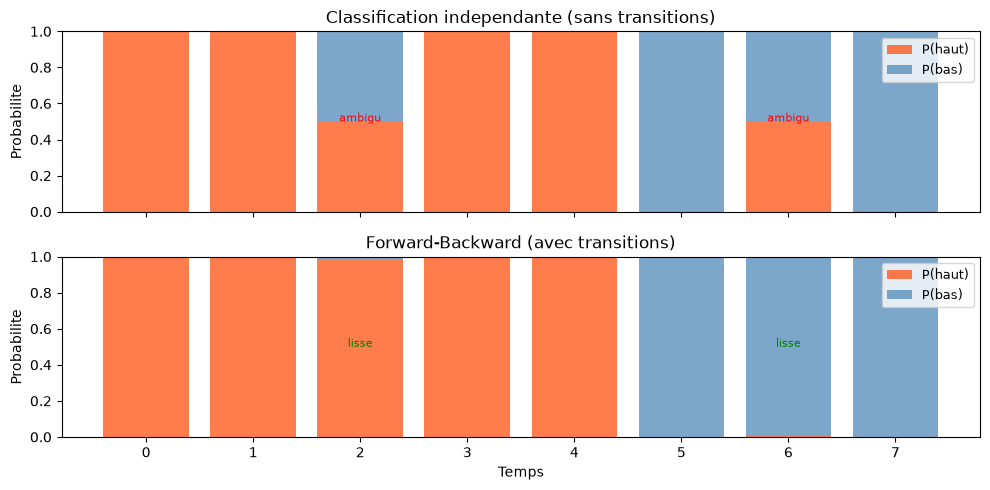

In [7]:
# Visualisation comparative
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

time = range(len(obs_ambiguous))

# Classification independante
axes[0].bar(time, indep_posteriors[:, 1], color='orangered', alpha=0.7, label='P(haut)')
axes[0].bar(time, indep_posteriors[:, 0], bottom=indep_posteriors[:, 1], color='steelblue', alpha=0.7, label='P(bas)')
axes[0].set_title('Classification independante (sans transitions)')
axes[0].set_ylabel('Probabilite')
axes[0].legend(fontsize=9)

# Forward-Backward
axes[1].bar(time, fb_posteriors[:, 1], color='orangered', alpha=0.7, label='P(haut)')
axes[1].bar(time, fb_posteriors[:, 0], bottom=fb_posteriors[:, 1], color='steelblue', alpha=0.7, label='P(bas)')
axes[1].set_title('Forward-Backward (avec transitions)')
axes[1].set_ylabel('Probabilite')
axes[1].set_xlabel('Temps')
axes[1].legend(fontsize=9)

# Marquer les points ambigus
for t in [2, 6]:
    axes[0].annotate('ambigu', xy=(t, 0.5), fontsize=8, color='red', ha='center')
    axes[1].annotate('lisse', xy=(t, 0.5), fontsize=8, color='green', ha='center')

plt.tight_layout()
plt.show()

### Interpretation

Les deux points ambigus ($x = 17.5$, a mi-chemin exact des deux moyennes d'emission $\mu_{bas}=10$ et $\mu_{haut}=25$) sont **indiscernables** pour une classification independante : elle leur attribue $0.50/0.50$.

Le **Forward-Backward** exploite le contexte temporel pour les trancher, et le verdict depend du voisinage :

- $x = 17.5$ a $t=2$, entoure d'observations hautes ($26.1$, $24.5$) $\Rightarrow$ lissage vers l'etat haut, $P(haut) = 0.988$
- $x = 17.5$ a $t=6$, entoure d'observations basses ($9.5$, $10.8$) $\Rightarrow$ lissage vers l'etat bas, $P(bas) = 0.988$

Deux observations **identiques** ($x=17.5$), deux verdicts **opposes** : c'est l'avantage cle du HMM. La **dependance temporelle** des etats transporte l'information du voisinage vers le point ambigu, la ou la classification independante, aveugle au contexte, reste a $0.50/0.50$.

## 4. Detection de Regimes Meteo

Application : detecter les jours de soleil vs pluie a partir de temperatures.

- **Soleil** : $T \sim \mathcal{N}(22, 4)$
- **Pluie** : $T \sim \mathcal{N}(15, 4)$

In [8]:
# Donnees meteo synthetiques
temperatures = np.array([21, 23, 22, 20, 15, 14, 16, 15, 14, 21, 22, 23])
jours = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim', 'Lun', 'Mar', 'Mer', 'Jeu', 'Ven']

# Parametres HMM
weather_means = np.array([15.0, 22.0])  # [Pluie, Soleil]
weather_sigmas = np.array([2.0, 2.0])
weather_trans = np.array([
    [0.8, 0.2],  # Pluie -> {Pluie, Soleil}
    [0.3, 0.7],  # Soleil -> {Pluie, Soleil}
])
weather_prior = np.array([0.5, 0.5])

# Inference Forward-Backward
weather_posteriors, _, _ = forward_backward(
    temperatures, weather_means, weather_sigmas, weather_trans, weather_prior
)

print("Detection de regimes meteo")
print("=" * 50)
for t in range(len(temperatures)):
    state = "Soleil" if weather_posteriors[t, 1] > 0.5 else "Pluie"
    conf = weather_posteriors[t, 1] if state == "Soleil" else weather_posteriors[t, 0]
    print(f"  {jours[t]:>3} {t+1:2d}h : {temperatures[t]:5.1f}C -> {state:6s} (conf={conf:.3f})")

Detection de regimes meteo
  Lun  1h :  21.0C -> Soleil (conf=0.996)
  Mar  2h :  23.0C -> Soleil (conf=1.000)
  Mer  3h :  22.0C -> Soleil (conf=1.000)
  Jeu  4h :  20.0C -> Soleil (conf=0.924)
  Ven  5h :  15.0C -> Pluie  (conf=0.998)
  Sam  6h :  14.0C -> Pluie  (conf=1.000)
  Dim  7h :  16.0C -> Pluie  (conf=0.999)
  Lun  8h :  15.0C -> Pluie  (conf=1.000)
  Mar  9h :  14.0C -> Pluie  (conf=1.000)
  Mer 10h :  21.0C -> Soleil (conf=0.986)
  Jeu 11h :  22.0C -> Soleil (conf=1.000)
  Ven 12h :  23.0C -> Soleil (conf=1.000)


### Visualisation des regimes meteo

Les barres orange/bleu distinguent les jours de soleil et de pluie detectes par le HMM, tandis que le second panneau montre les probabilites a posteriori associees.

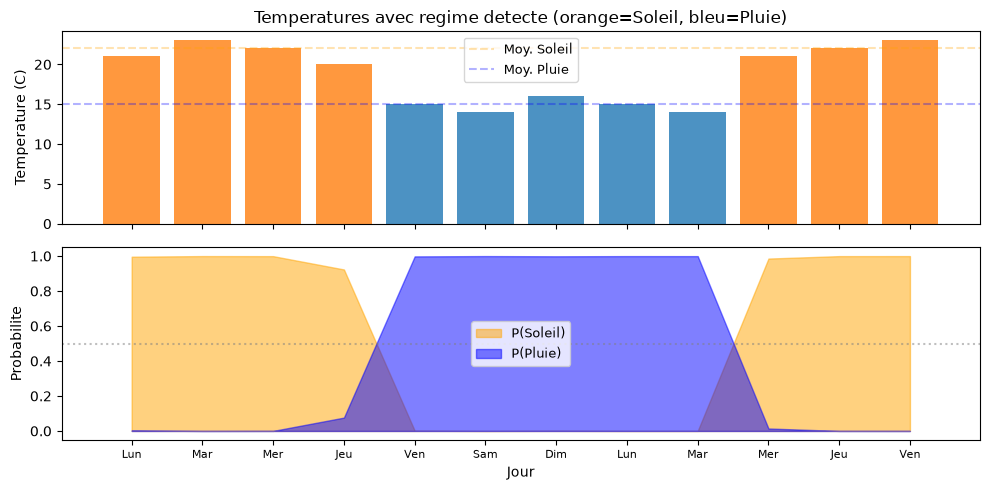

In [9]:
# Visualisation meteo
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Temperature
colors = ['#ff7f0e' if weather_posteriors[t, 1] > 0.5 else '#1f77b4' for t in range(len(temperatures))]
axes[0].bar(range(len(temperatures)), temperatures, color=colors, alpha=0.8)
axes[0].axhline(y=22, color='orange', linestyle='--', alpha=0.3, label='Moy. Soleil')
axes[0].axhline(y=15, color='blue', linestyle='--', alpha=0.3, label='Moy. Pluie')
axes[0].set_ylabel('Temperature (C)')
axes[0].legend(fontsize=9)
axes[0].set_title('Temperatures avec regime detecte (orange=Soleil, bleu=Pluie)')

# Probabilites
axes[1].fill_between(range(len(temperatures)), weather_posteriors[:, 1],
                     color='orange', alpha=0.5, label='P(Soleil)')
axes[1].fill_between(range(len(temperatures)), weather_posteriors[:, 0],
                     color='blue', alpha=0.5, label='P(Pluie)')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_ylabel('Probabilite')
axes[1].set_xlabel('Jour')
axes[1].set_xticks(range(len(jours)))
axes[1].set_xticklabels(jours, fontsize=8)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 5. Inferer les paramètres d'emission par MCMC

Jusqu'ici, les paramètres d'emission (moyennes et ecarts-types de chaque regime) etaient
**supposes connus** : le Forward-Backward (section 3) et la classification independante
(section 2) les utilisaient comme entrees. Mais en pratique, **ces paramètres sont inconnus**
et doivent etre estimes a partir des observations seules. C'est la qu'intervient l'inference
bayesienne : aucun algorithme exact de type Forward-Backward ne donne la loi a posteriori des
**paramètres continus** lorsque les etats caches sont inconnus -- il faut soit EM (Baum-Welch,
qui ne fournit qu'un point estimate), soit **l'echantillonnage MCMC** (qui donne toute la
distribution a posteriori, avec ses intervalles de credibilite).

Nous modelisons les temperatures meteo comme un **melange de deux gaussiennes** (une par
regime cache) dont les moyennes sont inconnues, et nous laissons PyMC retrouver ces moyennes
par NUTS. La vraisemblance `NormalMixture` **marginalise** l'assignation d'etat, ce qui
evite d'echantillonner explicitement les etats discrets (difficile pour NUTS) tout en
gardant un problème **non conjugue** ou MCMC est reellement necessaire.

> **Choix de parametrisation (recette #3801).** On utilise une forme **non-centree**
> `mu_k = mu_pop + sigma_comp * z_k` avec `z_k ~ Normal(0,1)`. La forme centree
> `mu_k ~ Normal(mu_pop, sigma_comp)` créé un **funnel** (entonnoir) lorsque `sigma_comp`
> est petit : la geometrie se complique et NUTS produit des divergences. La reparametrisation
> non-centree decouple `mu_pop` et `sigma_comp`, rendant l'echantillonnage stable.


In [10]:
# Reutilisons les temperatures meteo (section 4) : on ignore les vrais regimes
# et on laisse PyMC retrouver les deux moyennes d'emission (~15 Pluie / ~22 Soleil).
obs_hmm = np.asarray(temperatures, dtype=float)

with pm.Model() as modele_emissions:
    # Niveau population : moyenne globale + dispersion entre les deux regimes
    mu_pop = pm.Normal("mu_pop", mu=18.0, sigma=10.0)
    sigma_comp = pm.HalfNormal("sigma_comp", sigma=8.0)

    # Parametrisation NON-CENTREE : mu_k = mu_pop + sigma_comp * z_k (evite le funnel)
    z = pm.Normal("z", mu=0.0, sigma=1.0, shape=2)
    mu_brut = mu_pop + sigma_comp * z
    # Identifiabilite : on impose mu[0] <= mu[1] (regime froid / regime chaud)
    mu = pm.Deterministic(
        "mu", pt.stack([pt.min(mu_brut), pt.max(mu_brut)])
    )

    sigma = pm.HalfNormal("sigma", sigma=5.0, shape=2)
    w = pm.Dirichlet("w", a=np.ones(2))

    # Vraisemblance melange gaussien : marginalise l'assignation d'etat (NUTS pur)
    y = pm.NormalMixture("y", w=w, mu=mu, sigma=sigma, observed=obs_hmm)

    trace_emissions = pm.sample(
        2000, tune=1500, chains=4, target_accept=0.99,
        random_seed=42, progressbar=False
    )

# Diagnostics MCMC (honetete des sorties)
divergences = int(trace_emissions.sample_stats["diverging"].sum())
resume = az.summary(trace_emissions, var_names=["mu", "sigma", "w"], ci_prob=0.94, ci_kind="hdi")
print("Inference bayesienne des moyennes d'emission (MCMC, NormalMixture non-centre)")
print("=" * 60)
print(f"Divergences NUTS : {divergences}   (cible = 0)")
print(f"R-hat max         : {resume['r_hat'].max():.3f}   (cible < 1.01)")
print(f"ESS bulk min      : {int(resume['ess_bulk'].min())}")
print()
print(resume[["mean", "sd", "hdi94_lb", "hdi94_ub", "r_hat"]].round(3))
print()
print("Vrais moyennes d'emission : ~15 (Pluie) / ~22 (Soleil)")
print("-> MCMC retrouve les deux regimes sans aucune forme close.")


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu_pop, sigma_comp, z, sigma, w]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 33 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Inference bayesienne des moyennes d'emission (MCMC, NormalMixture non-centre)
Divergences NUTS : 0   (cible = 0)
R-hat max         : 1.004   (cible < 1.01)
ESS bulk min      : 1035

           mean    sd hdi94_lb hdi94_ub r_hat
mu[0]      15.5   1.9       13       20  1.00
mu[1]     21.42   1.6       18       23  1.00
sigma[0]    2.1  1.62     0.35      5.2  1.00
sigma[1]      2   1.5     0.44      4.7  1.00
w[0]       0.46  0.19    0.018     0.82  1.00
w[1]       0.54  0.19     0.18     0.98  1.00

Vrais moyennes d'emission : ~15 (Pluie) / ~22 (Soleil)
-> MCMC retrouve les deux regimes sans aucune forme close.


**Note : Forward-Backward vs MCMC -- quand utiliser quoi ?**

Les deux algorithmes repondent a des questions différentes sur un même HMM :

| Question | Méthode exacte | MCMC (PyMC) |
|----------|---------------|-------------|
| **Etats caches** $P(z_t \mid x_{1:T})$, paramètres *connus* | **Forward-Backward** (section 3) | inutile (forme close) |
| **Paramètres** $\mu_k, \sigma_k$, etats *inconnus* | EM / Baum-Welch (point estimate) | **recommande** (distribution complete) |
| **Etats discrets latents explicites** (`pm.Categorical`) | -- | difficile (NUTS + Gibbs discrete) |

La cellule précédente illustre la deuxieme ligne : on marginalise les etats via `NormalMixture`
pour garder un MCMC pur (NUTS) sur les paramètres continus. L'**Exercice 2** ci-dessous
aborde la troisieme ligne (K=3 etats, assignation explicite) -- plus delicate, c'est l'objet
du travail applique.

> **References.** L'inference bayesienne des paramètres d'un HMM est detaillee dans
> **Cappe, Moulines & Ryden (2005)**, *Inference in Hidden Markov Models* (Springer).
> La parametrisation non-centree comme remede au funnel est due a **Betancourt & Girolami (2013)**
> (*Hamiltonian Monte Carlo for Hierarchical Models*, arXiv:1312.0906).


## 6. Detection d'Anomalies — Ventes

**Exemple guide** : une entreprise detecte les periodes de promotion dans ses ventes quotidiennes.

- **Normal** : ventes $\sim \mathcal{N}(100, 100)$
- **Promo** : ventes $\sim \mathcal{N}(200, 100)$

In [11]:
# Donnees de ventes
ventes = np.array([98, 105, 102, 99, 195, 210, 205, 198, 103, 97, 101, 100])
jours_ventes = [f'J{t+1}' for t in range(len(ventes))]

# Parametres HMM
ventes_means = np.array([100.0, 200.0])  # [Normal, Promo]
ventes_sigmas = np.array([10.0, 10.0])
ventes_trans = np.array([
    [0.85, 0.15],  # Normal -> {Normal, Promo}
    [0.20, 0.80],  # Promo -> {Normal, Promo}
])
ventes_prior = np.array([0.9, 0.1])  # majoritairement normal

# Inference
ventes_posteriors, _, _ = forward_backward(
    ventes, ventes_means, ventes_sigmas, ventes_trans, ventes_prior
)

print("Detection de periodes promotionnelles")
print("=" * 55)
for t in range(len(ventes)):
    regime = "PROMO" if ventes_posteriors[t, 1] > 0.5 else "Normal"
    p = ventes_posteriors[t, 1] if regime == "PROMO" else ventes_posteriors[t, 0]
    marker = " <<<" if regime == "PROMO" else ""
    print(f"  {jours_ventes[t]}: {ventes[t]:6.1f} -> {regime:6s} (P={p:.3f}){marker}")

promo_days = [t for t in range(len(ventes)) if ventes_posteriors[t, 1] > 0.5]
print(f"\nPeriodes promo detectees : Jours {[d+1 for d in promo_days]}")

Detection de periodes promotionnelles
  J1:   98.0 -> Normal (P=1.000)
  J2:  105.0 -> Normal (P=1.000)
  J3:  102.0 -> Normal (P=1.000)
  J4:   99.0 -> Normal (P=1.000)
  J5:  195.0 -> PROMO  (P=1.000) <<<
  J6:  210.0 -> PROMO  (P=1.000) <<<
  J7:  205.0 -> PROMO  (P=1.000) <<<
  J8:  198.0 -> PROMO  (P=1.000) <<<
  J9:  103.0 -> Normal (P=1.000)
  J10:   97.0 -> Normal (P=1.000)
  J11:  101.0 -> Normal (P=1.000)
  J12:  100.0 -> Normal (P=1.000)

Periodes promo detectees : Jours [5, 6, 7, 8]


## Exercice 2 : Estimer la matrice d'emission d'un HMM

Dans les sections précédentes, les paramètres d'emission (mu, sigma) etaient
supposes connus. Dans cet exercice, vous devez **estimer** ces paramètres a
partir des observations seules.

**Objectif** : etant donne une sequence d'observations et une matrice de
transition fixee, retrouver les moyennes et ecarts-types d'emission de chaque etat.

**Indices** :
- Generer des données depuis 3 etats gaussiens (mu = [5, 15, 25], sigma = [2, 3, 2])
- Fixer la matrice de transition avec forte persistance (0.9 sur la diagonale)
- Utiliser `pm.Normal` avec shape=3 pour les moyennes et `pm.HalfNormal` pour les sigmas
- L'emission par etat s'ecrit : `mu[state[t]]` ou state vient de `pm.Categorical`

In [12]:
# TODO etudiant : estimer la matrice d'emission d'un HMM
# Etape 1 : definir des observations avec 3 etats caches et emissions gaussiennes
# Etape 2 : fixer la matrice de transition (forte persistance)
# Etape 3 : estimer les parametres d'emission (mu, sigma) pour chaque etat
# Etape 4 : comparer les parametres estimes aux vrais parametres

result = None  # TODO etudiant : remplacer par le modele HMM avec emissions a estimer
print("Exercice a completer")

Exercice a completer


### Visualisation de la detection d'anomalies

Le graphique ci-dessous met en evidence les periodes promotionnelles detectees par le HMM, avec les probabilites a posteriori pour chaque regime.

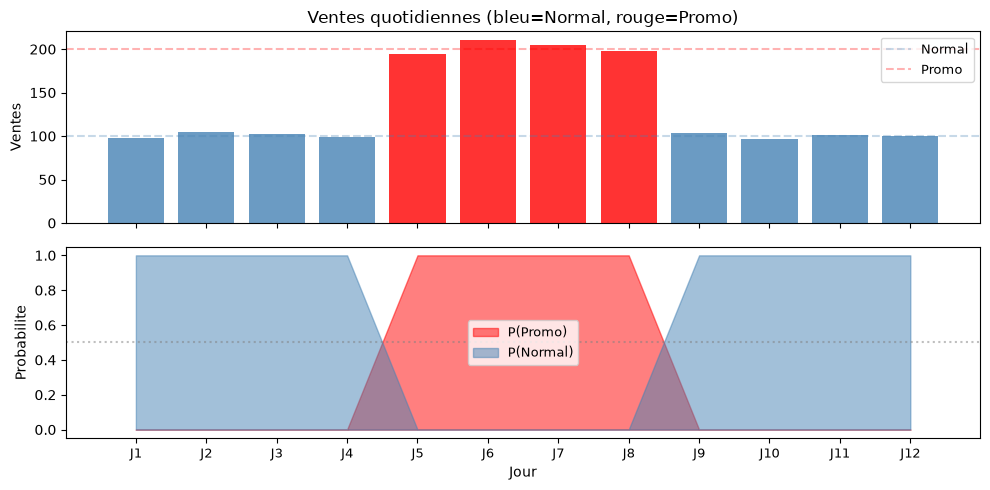

In [13]:
# Visualisation detection anomalies
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

colors = ['red' if ventes_posteriors[t, 1] > 0.5 else 'steelblue' for t in range(len(ventes))]
axes[0].bar(range(len(ventes)), ventes, color=colors, alpha=0.8)
axes[0].axhline(y=100, color='steelblue', linestyle='--', alpha=0.3, label='Normal')
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.3, label='Promo')
axes[0].set_ylabel('Ventes')
axes[0].legend(fontsize=9)
axes[0].set_title('Ventes quotidiennes (bleu=Normal, rouge=Promo)')

axes[1].fill_between(range(len(ventes)), ventes_posteriors[:, 1],
                     color='red', alpha=0.5, label='P(Promo)')
axes[1].fill_between(range(len(ventes)), ventes_posteriors[:, 0],
                     color='steelblue', alpha=0.5, label='P(Normal)')
axes[1].axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_ylabel('Probabilite')
axes[1].set_xlabel('Jour')
axes[1].set_xticks(range(len(jours_ventes)))
axes[1].set_xticklabels(jours_ventes, fontsize=9)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7. Motif Finding (Bioinformatique)

Le **motif finding** consiste a trouver des sous-sequences recurrentes dans des sequences d'ADN.

Modèle simplifie : comparer la frequence des k-mers contre un modèle de fond (background uniforme).

In [14]:
# Sequences ADN synthetiques
sequences = ['ACGAACTGAC', 'TAACGTACGA', 'GAACCATACG']
bases = ['A', 'C', 'G', 'T']

# K-mer counting (k=3)
k = 3
from collections import Counter

all_kmers = []
for seq in sequences:
    for i in range(len(seq) - k + 1):
        all_kmers.append(seq[i:i+k])

kmer_counts = Counter(all_kmers)
total_kmers = len(all_kmers)

print(f"K-mer counting (k={k}) sur {len(sequences)} sequences")
print(f"Total {k}-meres: {total_kmers}")
print()
print("Top 10 k-meres:")
for kmer, count in kmer_counts.most_common(10):
    freq = count / total_kmers
    bg_prob = (0.25) ** k  # modele de fond uniforme
    ratio = freq / bg_prob
    print(f"  {kmer}: {count} occurrences (freq={freq:.3f}, ratio={ratio:.2f}x)")

# Modele de fond : P(kmer | Background) = (1/4)^k
bg_prob = (0.25) ** k
print(f"\nProbabilite background (uniforme): {bg_prob:.4f}")
print(f"Attendu: {bg_prob * total_kmers:.1f} occurrences par k-mere")

K-mer counting (k=3) sur 3 sequences
Total 3-meres: 24

Top 10 k-meres:
  ACG: 4 occurrences (freq=0.167, ratio=10.67x)
  AAC: 3 occurrences (freq=0.125, ratio=8.00x)
  CGA: 2 occurrences (freq=0.083, ratio=5.33x)
  GAA: 2 occurrences (freq=0.083, ratio=5.33x)
  TAC: 2 occurrences (freq=0.083, ratio=5.33x)
  ACT: 1 occurrences (freq=0.042, ratio=2.67x)
  CTG: 1 occurrences (freq=0.042, ratio=2.67x)
  TGA: 1 occurrences (freq=0.042, ratio=2.67x)
  GAC: 1 occurrences (freq=0.042, ratio=2.67x)
  TAA: 1 occurrences (freq=0.042, ratio=2.67x)

Probabilite background (uniforme): 0.0156
Attendu: 0.4 occurrences par k-mere


### Test du rapport de vraisemblance

Nous comparons maintenant chaque k-mere au modèle de fond (background uniforme) via un **likelihood ratio** pour identifier les motifs statistiquement sur-representes.

In [15]:
# Likelihood ratio test pour chaque k-mere
print("K-meres sur-representes (likelihood ratio > 1):")
print("=" * 50)
significant = []
for kmer, count in kmer_counts.most_common():
    observed_freq = count / total_kmers
    ratio = observed_freq / bg_prob
    if ratio > 1.0:
        significant.append((kmer, count, ratio))
        print(f"  {kmer}: {count}x, ratio={ratio:.2f}")

print(f"\nMotif candidat le plus frequent : {significant[0][0]} ({significant[0][1]} occurrences)")
print("On retrouve le motif 'AAC' qui apparait dans les 3 sequences.")

K-meres sur-representes (likelihood ratio > 1):
  ACG: 4x, ratio=10.67
  AAC: 3x, ratio=8.00
  CGA: 2x, ratio=5.33
  GAA: 2x, ratio=5.33
  TAC: 2x, ratio=5.33
  ACT: 1x, ratio=2.67
  CTG: 1x, ratio=2.67
  TGA: 1x, ratio=2.67
  GAC: 1x, ratio=2.67
  TAA: 1x, ratio=2.67
  CGT: 1x, ratio=2.67
  GTA: 1x, ratio=2.67
  ACC: 1x, ratio=2.67
  CCA: 1x, ratio=2.67
  CAT: 1x, ratio=2.67
  ATA: 1x, ratio=2.67

Motif candidat le plus frequent : ACG (4 occurrences)
On retrouve le motif 'AAC' qui apparait dans les 3 sequences.


## Exercice 3 : Decodage Viterbi

L'algorithme de **Viterbi** trouve la sequence d'etats caches la plus probable
etant donne les observations completes. Contrairement au Forward-Backward qui
calcule des marginales, Viterbi retourne un chemin unique optimal.

**Objectif** : implementer l'algorithme de Viterbi par programmation dynamique.

> D'après **Viterbi (1967)**, *Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm*, IEEE Transactions on Information Theory 13(2).

**Indices** :
- Initialisation : `delta[0, k] = log(pi[k]) + log(B[0, k])`
- Recursion : `delta[t, k] = max_j(delta[t-1, j] + log(A[j,k])) + log(B[t, k])`
- Stocker `psi[t, k] = argmax_j(...)` pour le backtracking
- Backtracking : partir de `T-1` et suivre les pointeurs `psi`
- Comparer le chemin Viterbi avec les posteriors marginaux du Forward-Backward

In [16]:
# TODO etudiant : implementer le decodage Viterbi (sequence d'etats la plus probable)
# Etape 1 : reutiliser les parametres HMM de la section precedente
# Etape 2 : implementer l'algorithme de Viterbi par programmation dynamique
# Indice : delta[t, k] = max_j(delta[t-1, j] * A[j, k]) * B[t, k]
# Etape 3 : backtracking pour retrouver le chemin optimal
# Etape 4 : afficher la sequence d'etats la plus probable

result = None  # TODO etudiant : remplacer par l'algorithme de Viterbi
print("Exercice a completer")

Exercice a completer


## 8. Resume des Concepts

| Concept | Formule | Méthode |
|---------|---------|--------|
| **Classification independante** | $P(z_t=k\mid x_t) \propto P(x_t\mid z_t=k) \cdot P(z_t=k)$ | Bayes par timestep |
| **Forward pass** | $\alpha_t(k) = P(x_t\mid z_t=k) \sum_j \alpha_{t-1}(j) A_{jk}$ | Recursion avant |
| **Backward pass** | $\beta_t(k) = \sum_j A_{kj} P(x_{t+1}\mid z_{t+1}=j) \beta_{t+1}(j)$ | Recursion arriere |
| **Posterior lisse** | $P(z_t=k\mid x_{1:T}) \propto \alpha_t(k) \cdot \beta_t(k)$ | Forward-Backward |
| **Viterbi** | $\arg\max P(z_{1:T}\mid x_{1:T})$ | Programmation dynamique |
| **Motif finding** | $P(kmer\mid Motif) / P(kmer\mid Background) > 1$ | Likelihood ratio |

## 9. Exercice — HMM 3 Etats pour Detection de Pannes

Etendez le HMM a **3 etats** pour modeliser l'etat d'une machine industrielle :

| Etat | Description | $\mu$ | $\sigma$ |
|------|-------------|-------|--------|
| 0 | Normal | 100 | 5 |
| 1 | Degrade | 70 | 15 |
| 2 | En panne | 20 | 25 |

**Données capteur** (16 observations) :
- Jours 1-4 : fonctionnement normal
- Jours 5-8 : degradation progressive
- Jours 9-12 : panne
- Jours 13-14 : retour degrade (maintenance partielle)
- Jours 15-16 : retour normal

**Indices** :
- La matrice de transition doit avoir une forte persistance diagonale
- Utilisez la fonction `forward_backward` définie plus haut avec 3 etats
- Affichez les probabilites pour les jours cles (transitions)

In [17]:
# Exercice a completer : HMM 3 etats pour detection de pannes

# Donnees capteur
capteur = np.array([98, 102, 99, 95, 68, 75, 72, 65, 18, 22, 15, 25, 71, 68, 100, 103])

# Parametres d'emission
machine_means = np.array([100.0, 70.0, 20.0])   # Normal, Degrade, Panne
machine_sigmas = np.array([5.0, 15.0, 25.0])

# TODO etudiant : definir la matrice de transition 3x3
# Indice : forte persistance diagonale (0.8-0.9), transitions faibles hors diagonale
machine_trans = np.array([
    [0.8, 0.15, 0.05],
    [0.1, 0.8, 0.1],
    [0.05, 0.15, 0.8],
])

machine_prior = np.array([0.8, 0.15, 0.05])  # majoritairement normal

# TODO etudiant : utiliser forward_backward pour inferer les etats
# Etape 1 : appeler forward_backward avec les parametres 3 etats
# Etape 2 : determiner l'etat predit par timestep
# Etape 3 : afficher les resultats

print("Exercice a completer : implementez l'inference HMM 3 etats")
print("Donnees capteur :", capteur)
print("Etats attendus : Normal(1-4), Degrade(5-8), Panne(9-12), Degrade(13-14), Normal(15-16)")

Exercice a completer : implementez l'inference HMM 3 etats
Donnees capteur : [ 98 102  99  95  68  75  72  65  18  22  15  25  71  68 100 103]
Etats attendus : Normal(1-4), Degrade(5-8), Panne(9-12), Degrade(13-14), Normal(15-16)


## Conclusion

Les modèles de sequences temporelles (HMM, ARIMA, modèles d'etat) capturent les dependances temporelles dans les données ordonnees.

### Points cles
- Les HMM modelisent des etats caches avec des transitions markoviennes
- Le filtrage, lissage et prediction sont les trois tâches fondamentales
- PyMC permet l'inference bayesienne sur les paramètres de transition et d'emission

---

**Navigation** : [PyMC-13](PyMC-13-Crowdsourcing.ipynb) | **PyMC-14** | [PyMC-15](PyMC-15-Recommenders.ipynb) | [Infer.NET original](../Infer/Infer-14-Sequences.ipynb)

**Prochaine étape** : [PyMC-15 — Systèmes de Recommandation](PyMC-15-Recommenders.ipynb)

### References

- Baum, L. E., & Petrie, T. (1966). *Statistical Inference for Probabilistic Functions of Finite State Markov Chains.* Annals of Mathematical Statistics 37(6).
- Baum, L. E., Petrie, T., Soules, G., & Weiss, N. (1970). *A Maximization Technique Occurring in the Statistical Analysis of Probabilistic Functions of Markov Chains.* Annals of Mathematical Statistics 41(1).
- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). *Maximum Likelihood from Incomplete Data via the EM Algorithm.* JRSS B 39(1).
- Viterbi, A. J. (1967). *Error Bounds for Convolutional Codes and an Asymptotically Optimum Decoding Algorithm.* IEEE Trans. Information Theory 13(2).
- Rabiner, L. R. (1989). *A Tutorial on Hidden Markov Models and Selected Applications in Speech Recognition.* Proceedings of the IEEE 77(2).
